# Modulo 3 - Autocorrelacion (ACF) y autocorrelacion parcial (PACF) en Python

Curso: **Series Temporales con R y Python** (Frogames Formacion).

Codigo de acompanamiento de la leccion `03-caracteristicas-fundamentales/03-autocorrelacion-acf-y-pacf`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as sgt

np.random.seed(42)

df_comp = pd.read_csv("indices_2015_2026.csv", parse_dates=["date"], index_col="date")
df_comp = df_comp.asfreq('B')
df_comp.spx = df_comp.spx.ffill()
df_comp.ftse = df_comp.ftse.bfill()
df_comp.dax = df_comp.dax.fillna(value=df_comp.dax.mean())
df_comp.nikkei = df_comp.nikkei.ffill().bfill()
df_comp['market_value'] = df_comp.spx
df_comp = df_comp[['market_value']]

size = int(len(df_comp) * 0.8)
df = df_comp.iloc[:size].copy()

wn = np.random.normal(loc=df.market_value.mean(), scale=df.market_value.std(), size=len(df))
df['wn'] = wn

steps = np.random.normal(loc=0, scale=1, size=len(df))
steps[0] = 0
df['rw'] = df.market_value.iloc[0] + np.cumsum(steps) * (df.market_value.std() * 0.01)
df.head(2)

,market_value,wn,rw
date,,,
2015-01-02,2058.199951,3663.742169,2058.199951
2015-01-05,2020.579956,3072.006838,2064.627326


## ACF: autocorrelacion simple

La funcion de autocorrelacion (ACF) mide cuanto se parece la serie a si misma desplazada k periodos (lags), para k = 1, 2, 3... Es la primera herramienta cuantitativa para responder "cuanto depende el valor de hoy de los valores anteriores".

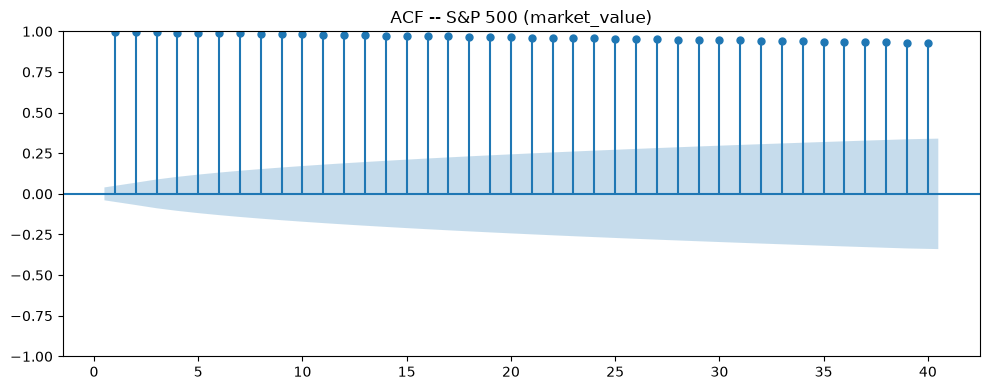

In [2]:
fig, ax = plt.subplots(figsize=(10, 4))
sgt.plot_acf(df.market_value, lags=40, zero=False, ax=ax)
ax.set_title('ACF -- S&P 500 (market_value)')
plt.tight_layout()
plt.savefig('acf_market.png', dpi=130)
plt.show()

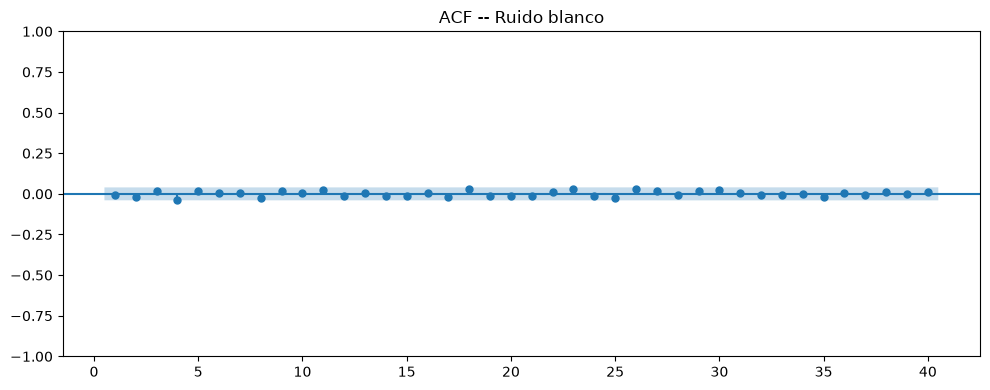

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
sgt.plot_acf(df.wn, lags=40, zero=False, ax=ax)
ax.set_title('ACF -- Ruido blanco')
plt.tight_layout()
plt.savefig('acf_wn.png', dpi=130)
plt.show()

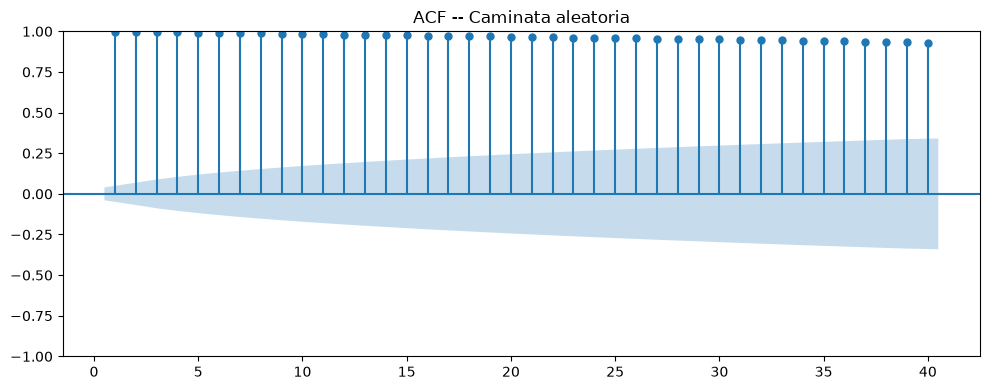

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
sgt.plot_acf(df.rw, lags=40, zero=False, ax=ax)
ax.set_title('ACF -- Caminata aleatoria')
plt.tight_layout()
plt.savefig('acf_rw.png', dpi=130)
plt.show()

## PACF: autocorrelacion parcial

La PACF mide la correlacion entre la serie y su version desplazada k periodos, pero eliminando el efecto ya explicado por los lags intermedios (1, ..., k-1). Es la herramienta que, en el Modulo 5, se usa para elegir el orden de un modelo AR.

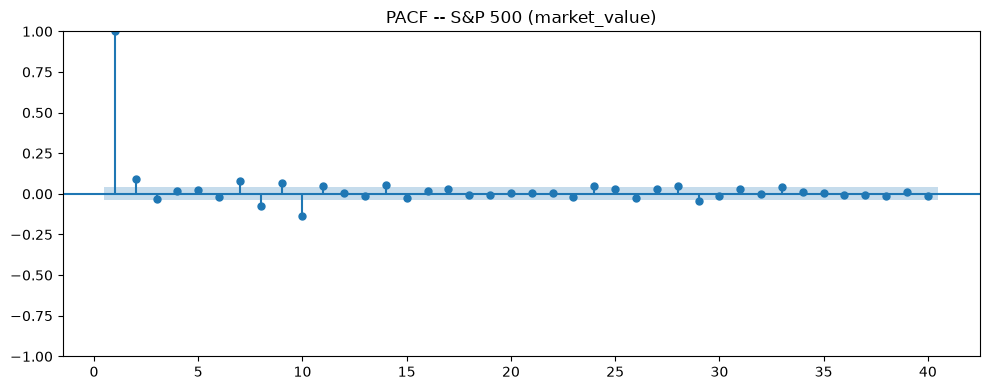

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
sgt.plot_pacf(df.market_value, lags=40, zero=False, method='ols', ax=ax)
ax.set_title('PACF -- S&P 500 (market_value)')
plt.tight_layout()
plt.savefig('pacf_market.png', dpi=130)
plt.show()

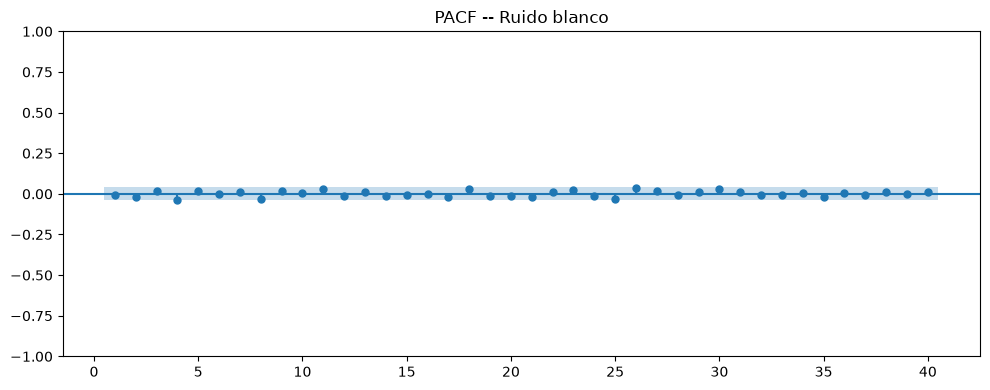

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
sgt.plot_pacf(df.wn, lags=40, zero=False, method='ols', ax=ax)
ax.set_title('PACF -- Ruido blanco')
plt.tight_layout()
plt.savefig('pacf_wn.png', dpi=130)
plt.show()

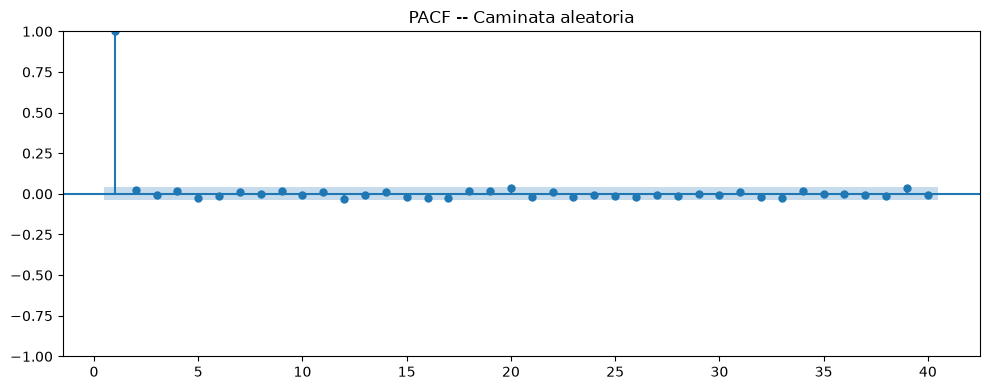

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
sgt.plot_pacf(df.rw, lags=40, zero=False, method='ols', ax=ax)
ax.set_title('PACF -- Caminata aleatoria')
plt.tight_layout()
plt.savefig('pacf_rw.png', dpi=130)
plt.show()

**Entregable**: reproduce estas celdas. Calcula el ACF de los RETORNOS del S&P 500 (en vez del precio) y compara el patron contra el ACF del precio -- es la diferencia que vas a explotar en el Modulo 5 (modelos AR).